In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#generate 100 samples, each sample has 2 features, points above: class1, points below: class0
np.random.seed(42) # 
n = 100
X = np.random.randn(n, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int) #x1 + x2 = 0

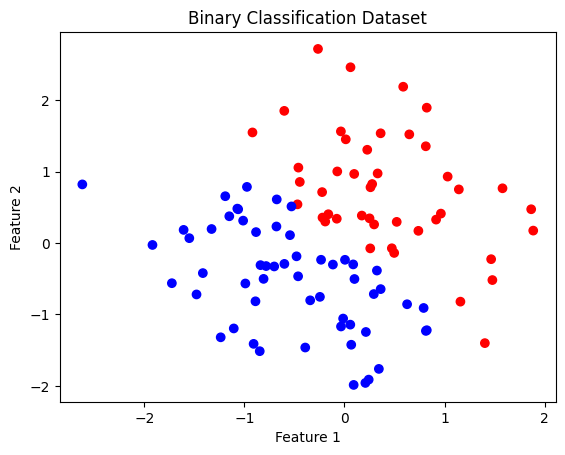

In [4]:
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap='bwr'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

In [ ]:
# z = Wx + b
# initially W=[0,0], b = 0
n_features = X.shape[1]

W = np.zeros((n_features,1))
b = 0

In [ ]:
y = y.reshape(-1,1)
#(100,0) becomes (100,1)

In [ ]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

#maps values to 0 to 1

In [13]:
#forward propogation
# z = Wx + b
# y_cap = sigmoid (z)
def forward(X,W,b):

    z = np.dot(X,W)+b

    y_hat = sigmoid(z)

    return y_hat

In [14]:
#Binary cross entropy loss
def compute_loss(y,y_hat):

    m = len(y)

    loss = -(1/m)*np.sum(
        y*np.log(y_hat+1e-15)+
        (1-y)*np.log(1-y_hat+1e-15)
    )

    return loss

In [15]:
#Compute Gradients
def gradients(X,y,y_hat):

    m = len(y)

    dW = (1/m)*np.dot(X.T,(y_hat-y))

    db = (1/m)*np.sum(y_hat-y)

    return dW,db

In [17]:
# Forward propagation
y_hat = forward(X, W, b)

# Compute gradients
dw, db = gradients(X, y, y_hat)

# Gradient descent update
learning_rate = 0.1

W = W - learning_rate * dw
b = b - learning_rate * db

In [19]:
epochs = 1000

losses = []

for epoch in range(epochs):

    y_hat = forward(X,W,b)

    loss = compute_loss(y,y_hat)

    dW,db = gradients(X,y,y_hat)

    W -= 0.1*dW
    b -= 0.1*db

    losses.append(loss)

    if epoch%100==0:
        print(epoch,loss)

0 0.6626836148802253
100 0.2712143142484928
200 0.20803605835432304
300 0.17853911448537427
400 0.1603948923204705
500 0.1477013196242138
600 0.13813050003967528
700 0.13055168543718496
800 0.1243392224778028
900 0.11911437954691806


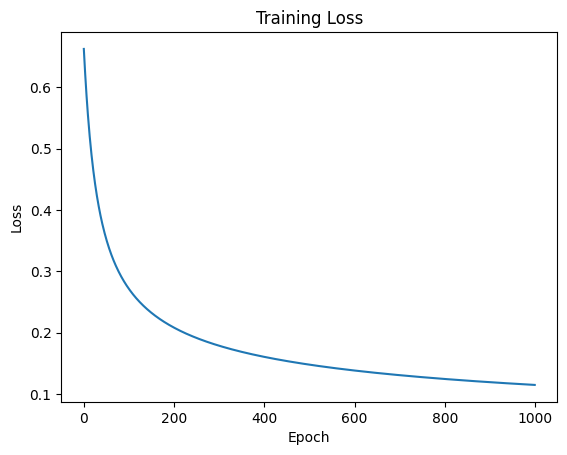

In [20]:
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.show()

In [21]:
def predict(X,W,b):

    probs = forward(X,W,b)

    return (probs>=0.5).astype(int)

In [22]:
predictions = predict(X,W,b)

accuracy = np.mean(predictions==y)

print("Accuracy:",accuracy)

Accuracy: 0.99
